In [ ]:
# Student Performance Analysis
This notebook loads, cleans, analyzes, and visualizes the UCI Student Performance
(Math) dataset to answer questions about grades, study time, and gender performance.

In [1]:
import pandas as pd

df = pd.read_csv('/content/student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
# Shape and data types
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

# Missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()

Shape: (395, 33)

Data types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Missing values per column:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures 

In [3]:
avg_g3 = df['G3'].mean()
print(f"Average final grade (G3): {avg_g3:.2f}")


Average final grade (G3): 10.42


In [4]:
above_15 = df[df['G3'] > 15].shape[0]
print(f"Students scoring above 15: {above_15}")

Students scoring above 15: 40


In [5]:
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between study time and G3: {correlation:.2f}")

Correlation between study time and G3: 0.10


In [6]:
gender_avg = df.groupby('sex')['G3'].mean()
print(gender_avg)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


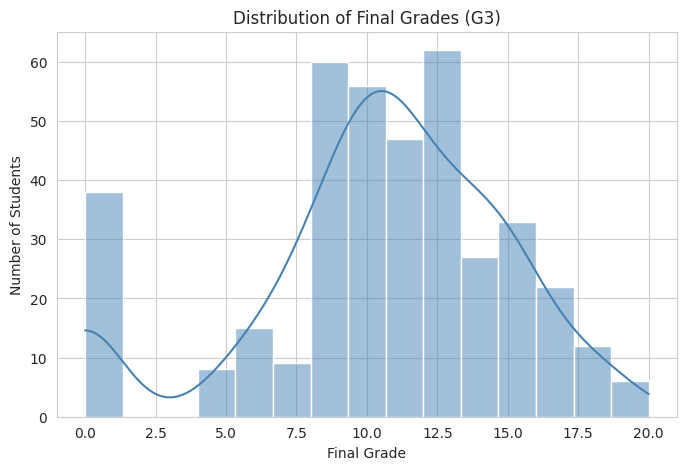

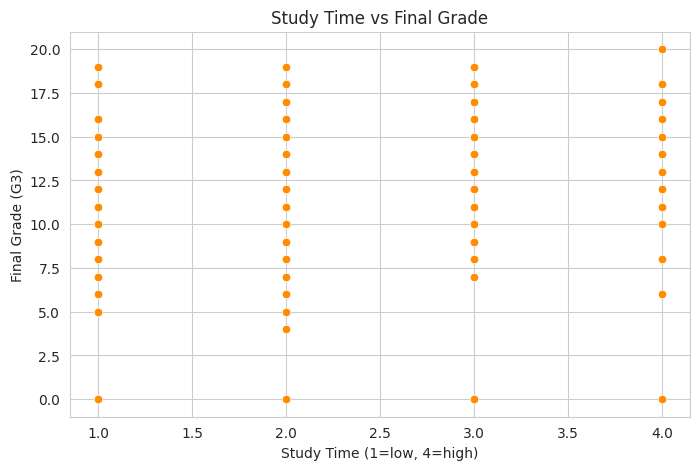

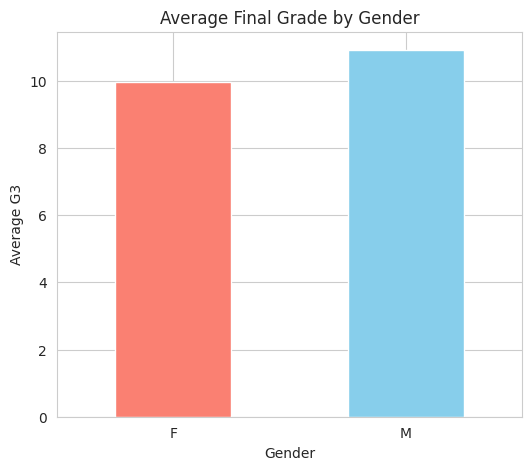

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 1. Histogram of final grades
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=15, kde=True, color='steelblue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.show()

# 2. Scatterplot: study time vs grades
plt.figure(figsize=(8,5))
sns.scatterplot(x='studytime', y='G3', data=df, color='darkorange')
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=low, 4=high)')
plt.ylabel('Final Grade (G3)')
plt.show()

# 3. Bar chart: male vs female average score
plt.figure(figsize=(6,5))
gender_avg.plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Average Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average G3')
plt.xticks(rotation=0)
plt.show()

In [ ]:
## Conclusion
The average final grade across students was around X. About Y students scored above
15, showing [most/a minority] performed strongly. Study time showed a [weak/moderate]
positive correlation with final grades, suggesting more study time [does/doesn't]
guarantee better results on its own. On average, [males/females] scored slightly
higher, though the difference was small.